In [1]:
import pandas as pd
import numpy as np
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
from pathlib import Path

data_folder = Path.cwd()/"CSV"

In [14]:
# Data Import: FCR
fcr = pd.read_csv(data_folder/"FCR_NL2024.csv")
col = "NETHERLANDS_SETTLEMENTCAPACITY_PRICE_[EUR/MW]"

# Set missing values to NaN
fcr[col] = pd.to_numeric(
    fcr[col].replace("-", np.nan),   
    errors="coerce"
)

n_missing = fcr[col].isna().sum()
print("Number of missing prices:", n_missing)

# data cleaning 
fcr["DATE_FROM"] = pd.to_datetime(fcr["DATE_FROM"])
hours = fcr["PRODUCTNAME"].str.extract(r"(\d{2})_(\d{2})").astype(int)
fcr["start_hour"] = hours[0]
fcr["end_hour"] = hours[1]
fcr["hour"] = fcr.apply(
    lambda row: list(range(row["start_hour"], row["end_hour"])),
    axis=1
)
fcr = fcr.explode("hour")
fcr["datetime"] = fcr["DATE_FROM"] + pd.to_timedelta(fcr["hour"], unit="h")

fcr = fcr.drop(columns=["PRODUCTNAME", "start_hour", "end_hour", "hour"])

fcr["datetime"] = pd.to_datetime(fcr["datetime"], utc=True)
fcr = fcr.sort_values("datetime").set_index("datetime")
fcr = (
    fcr[["NETHERLANDS_SETTLEMENTCAPACITY_PRICE_[EUR/MW]"]]            
    .rename(columns={"NETHERLANDS_SETTLEMENTCAPACITY_PRICE_[EUR/MW]": "FCR_capacity_EUR/MW"})                
)
print(fcr.head())

Number of missing prices: 156
                           FCR_capacity_EUR/MW
datetime                                      
2024-01-01 00:00:00+00:00                  NaN
2024-01-01 01:00:00+00:00                  NaN
2024-01-01 02:00:00+00:00                  NaN
2024-01-01 03:00:00+00:00                  NaN
2024-01-01 04:00:00+00:00                  NaN


In [15]:
# Data Import: aFRR Capacity
afrr_cap = pd.read_csv(data_folder / "capacity_aFRR_NL.csv")

afrr_cap["datetime"] = pd.to_datetime(afrr_cap["datetime"], utc=True)
afrr_cap["Down"] = pd.to_numeric(afrr_cap["Down"])

afrr_cap = (
    afrr_cap
    .set_index("datetime")                    
    .resample("1h")["Down"].mean()             
    .to_frame(name="aFRR_capacity_DOWN_EUR/MW")   
)

print(afrr_cap.head())

                           aFRR_capacity_DOWN_EUR/MW
datetime                                            
2023-12-31 23:00:00+00:00                       16.9
2024-01-01 00:00:00+00:00                       16.9
2024-01-01 01:00:00+00:00                       16.9
2024-01-01 02:00:00+00:00                       16.9
2024-01-01 03:00:00+00:00                       16.9


In [16]:
# Data Import: aFRR Activation
afrr_act = pd.read_csv(data_folder / "activated_aFRR_NL.csv")

afrr_act = afrr_act[afrr_act["Direction"] == "Down"].copy()
afrr_act["datetime"] = pd.to_datetime(afrr_act["datetime"], utc=True)

afrr_act["Price"] *= -1

afrr_act = (
    afrr_act
    .set_index("datetime")
    .resample("1h")["Price"].mean()
    .to_frame(name="aFRR_activation_DOWN_EUR/MW")

)

print(afrr_act.head())


                           aFRR_activation_DOWN_EUR/MW
datetime                                              
2023-12-31 23:00:00+00:00                      11.6800
2024-01-01 00:00:00+00:00                      13.1775
2024-01-01 01:00:00+00:00                      19.4725
2024-01-01 02:00:00+00:00                      15.7825
2024-01-01 03:00:00+00:00                      13.7900


In [17]:
# Combine all three on their datetime index
best_case_revenue = pd.concat(
    [fcr, afrr_cap, afrr_act],
    axis=1
)

# Make sure columns are in the order you want
best_case_revenue = best_case_revenue[
    ["FCR_capacity_EUR/MW",
     "aFRR_capacity_DOWN_EUR/MW",
     "aFRR_activation_DOWN_EUR/MW"]
]

# Add sum of FCR + aFRR capacity
best_case_revenue["total_capacity_revenue_EUR/MW"] = (
    best_case_revenue["FCR_capacity_EUR/MW"]
    + best_case_revenue["aFRR_capacity_DOWN_EUR/MW"]
)

# Add sum of all three (FCR + aFRR cap + aFRR activation)
best_case_revenue["total_revenue_EUR/MW"] = (
    best_case_revenue["FCR_capacity_EUR/MW"]
    + best_case_revenue["aFRR_capacity_DOWN_EUR/MW"]
    + best_case_revenue["aFRR_activation_DOWN_EUR/MW"]
)

print(best_case_revenue.head())


                           FCR_capacity_EUR/MW  aFRR_capacity_DOWN_EUR/MW  \
datetime                                                                    
2023-12-31 23:00:00+00:00                  NaN                       16.9   
2024-01-01 00:00:00+00:00                  NaN                       16.9   
2024-01-01 01:00:00+00:00                  NaN                       16.9   
2024-01-01 02:00:00+00:00                  NaN                       16.9   
2024-01-01 03:00:00+00:00                  NaN                       16.9   

                           aFRR_activation_DOWN_EUR/MW  \
datetime                                                 
2023-12-31 23:00:00+00:00                      11.6800   
2024-01-01 00:00:00+00:00                      13.1775   
2024-01-01 01:00:00+00:00                      19.4725   
2024-01-01 02:00:00+00:00                      15.7825   
2024-01-01 03:00:00+00:00                      13.7900   

                           total_capacity_revenue_EUR

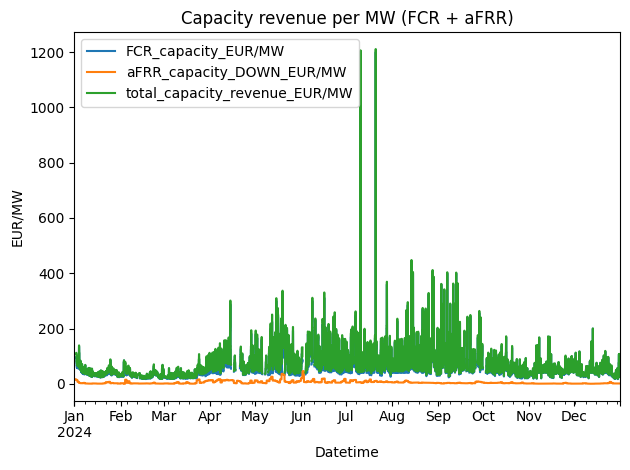

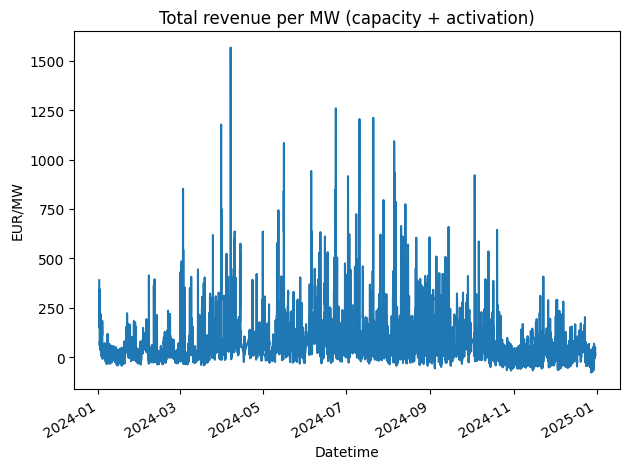

In [18]:
cap = best_case_revenue[
    ["FCR_capacity_EUR/MW", "aFRR_capacity_DOWN_EUR/MW", "total_capacity_revenue_EUR/MW"]
].dropna(how="all")

# 1) Capacity revenue only (FCR, aFRR_cap, and their sum)
fig, ax = plt.subplots()
cap.plot(ax=ax)
ax.set_title("Capacity revenue per MW (FCR + aFRR)")
ax.set_ylabel("EUR/MW")
ax.set_xlabel("Datetime")
plt.tight_layout()
plt.show()

# 2) Total revenue (capacity + activation)
tot = best_case_revenue["total_revenue_EUR/MW"].dropna()

fig, ax = plt.subplots()
tot.plot(ax=ax)
ax.set_title("Total revenue per MW (capacity + activation)")
ax.set_ylabel("EUR/MW")
ax.set_xlabel("Datetime")
plt.tight_layout()
plt.show()

In [20]:
min_max = best_case_revenue.agg(['min', 'max'])
print(min_max)

     FCR_capacity_EUR/MW  aFRR_capacity_DOWN_EUR/MW  \
min                17.21                       0.38   
max              1200.00                      46.15   

     aFRR_activation_DOWN_EUR/MW  total_capacity_revenue_EUR/MW  \
min                     -115.475                          18.75   
max                     1493.100                        1210.91   

     total_revenue_EUR/MW  
min                -76.99  
max               1566.13  
